# Three Tiers, One Task — Free vs. Cheap vs. Premium

**Run this notebook in Google Colab.** It sends the *same* small business task to
three AI tiers and shows what each one costs.

| Tier | How | API key? | When it's the right choice |
|---|---|---|---|
| **Gemini** | `google.colab.ai` (built into Colab) | no | exploring, learning — **free** |
| **DeepSeek** | OpenAI-compatible API | yes (cheap) | **automation** — it runs *without you* |
| **Claude** | Anthropic API | yes | the hardest, highest-stakes jobs |

**The task:** label each product with a *gift appeal* (High / Medium / Low) and a
one-line marketing blurb — judgement no formula in your data can compute.

**The lesson:** free Gemini is perfect while *you* sit in the notebook and click
**Run**. The moment AI must run **without you** — a nightly script, an app, a
scheduled job (Block 6!) — you need a real API key, and DeepSeek shows that can
cost a *fraction of a cent*.

> **Sending data out?** These product names aren't sensitive. For real customer or
> financial data, remember DeepSeek's API is China-hosted — right-size *what data*
> you send, not just which model.


In [ ]:
# One-time setup (Colab): install the two SDKs the paid tiers use.
# Gemini needs nothing extra — it is built into Colab.
!pip install -q openai anthropic


In [ ]:
%%writefile tier_lab.py
"""
tier_lab.py — helpers for the three-tier "same task" Colab notebook
(llm-tiers-colab.ipynb).

The lesson: the SAME small business task runs on three tiers —

    Gemini   (free, inside Colab, no key)     -> for exploring / learning
    DeepSeek (cheap, needs an API key)         -> for automation: it runs WITHOUT you
    Claude   (premium, needs an API key)       -> for the hardest, highest-stakes jobs

The task: label each product with a `gift_appeal` (High/Medium/Low) and a one-line
marketing `blurb` — judgement that no formula in the data can compute.

Design notes
------------
- `run_gemini` / `run_deepseek` / `run_claude` are SELF-GATING: each returns a
  result dict with ok=False and a human message when its tier is unavailable
  (not in Colab, or no key) instead of raising. So the notebook ships
  pre-executed and the smoke test runs with no Colab and no keys.
- `gemini` is free: `ai.generate_text()` returns only text (no token counts), so
  its cost is $0 by definition (free tier, monthly limit).
- Pure helpers (build_prompt, parse_labels, usd_cost, make_cost_chart) need no
  network and are what the smoke test exercises.
"""

import json
import os
import time

import matplotlib
matplotlib.use("Agg")  # headless backend — must precede any pyplot import
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------------
# The task input: a readable slice of the Adriatica catalogue (12 of 60
# products, spread across categories/tiers). Swap in all 60 to label the whole
# catalogue — the call stays one request and a fraction of a cent.
# ---------------------------------------------------------------------------
PRODUCTS = [
    "Smart Headphones 007",
    "Premium Hair Dryer 039",
    "Basic Pan Set 021",
    "Family Tent 034",
    "Premium Puzzle 044",
    "Mini Monitor Stand 054",
    "Travel Power Bank 003",
    "Deluxe Tent 029",
    "Classic Mirror 038",
    "Pro Notebook Set 056",
    "Smart Yoga Mat 025",
    "Family Skincare Set 040",
]

# Prices per 1M tokens (reused from the workshop's verified figures, 2026-06-19).
# Gemini-in-Colab is free, so it has no entry here.
TIER_PRICES = {
    "DeepSeek V4 Flash": (0.14, 0.28),
    "Claude Opus 4.8":   (5.0, 25.0),
}

# Model identifiers per tier.
GEMINI_MODEL = "google/gemini-2.5-flash"      # free tier in Colab
DEEPSEEK_MODEL = "deepseek-v4-flash"          # OpenAI-compatible
CLAUDE_MODEL = "claude-opus-4-8"
DEEPSEEK_BASE_URL = "https://api.deepseek.com"

# Illustrative cost-per-run for the comparison chart when a tier did not run
# live (clearly labelled in the chart title). Order = display order.
ILLUSTRATIVE = [
    {"tier": "Gemini (free, in Colab)", "usd_cost": 0.0},
    {"tier": "DeepSeek (key)",          "usd_cost": 0.00017},
    {"tier": "Claude (key)",            "usd_cost": 0.0105},
]


# ---------------------------------------------------------------------------
# Pure helpers (no network) — exercised by the smoke test
# ---------------------------------------------------------------------------
def build_prompt(products=None) -> str:
    """Build the catalogue-labelling instruction sent to every tier."""
    products = list(products) if products is not None else PRODUCTS
    listing = "\n".join(f"- {p}" for p in products)
    return (
        "You are a retail merchandiser. For each product below, decide its gift "
        "appeal (exactly one of: High, Medium, Low) and write a one-sentence "
        "marketing blurb.\n"
        'Return ONLY a JSON array of objects with keys "product_name", '
        '"gift_appeal", "blurb". No prose, no code fences.\n\n'
        f"Products:\n{listing}"
    )


def parse_labels(text: str) -> list:
    """
    Parse a model's reply into a list of {product_name, gift_appeal, blurb}.

    Tolerant of ```json fenced blocks and of a top-level object that wraps the
    array under some key.
    """
    t = (text or "").strip()
    if t.startswith("```"):
        # drop the opening fence (``` or ```json) and the trailing fence
        t = t.split("```", 2)[1] if t.count("```") >= 2 else t.strip("`")
        if t.lstrip().lower().startswith("json"):
            t = t.lstrip()[4:]
        t = t.strip()
    try:
        data = json.loads(t)
    except json.JSONDecodeError:
        # Fallback: pull out the outermost [...] array if the model added prose.
        i, j = t.find("["), t.rfind("]")
        if i != -1 and j > i:
            data = json.loads(t[i:j + 1])
        else:
            raise
    if isinstance(data, dict):
        # e.g. {"products": [...]} — take the first list value
        for value in data.values():
            if isinstance(value, list):
                data = value
                break
    if not isinstance(data, list):
        raise ValueError("Parsed reply is not a JSON array of products")
    return data


def usd_cost(model_name: str, input_tokens: int, output_tokens: int) -> float:
    """Cost of one call for a priced tier (Gemini is free → not in TIER_PRICES)."""
    in_price, out_price = TIER_PRICES[model_name]
    return round(input_tokens * in_price / 1e6 + output_tokens * out_price / 1e6, 8)


def _result(tier, model, ok, rows=None, input_tokens=None, output_tokens=None,
            cost=None, latency_s=None, note=""):
    return {
        "tier": tier,
        "model": model,
        "ok": ok,
        "rows": rows or [],
        "n": len(rows) if rows else 0,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "usd_cost": cost,
        "latency_s": latency_s,
        "note": note,
    }


# ---------------------------------------------------------------------------
# Tier runners — self-gating (return ok=False instead of raising)
# ---------------------------------------------------------------------------
def run_gemini(products=None, model_name=GEMINI_MODEL):
    """Tier 1 — free Gemini via google.colab.ai. Only works inside Colab."""
    try:
        from google.colab import ai  # noqa: import only available in Colab
    except Exception:
        return _result(
            "Gemini (free, in Colab)", model_name, ok=False,
            note="Not running in Colab — open this notebook in Google Colab to "
                 "use the free Gemini tier (no API key needed).",
        )
    prompt = build_prompt(products)
    t0 = time.time()
    try:
        text = ai.generate_text(prompt, model_name=model_name)
        rows = parse_labels(text)
    except Exception as exc:
        return _result("Gemini (free, in Colab)", model_name, ok=False,
                       note=f"Gemini call/parse failed: {exc}")
    # Free tier: no token counts returned, and cost is $0.
    return _result(
        "Gemini (free, in Colab)", model_name, ok=True, rows=rows,
        cost=0.0, latency_s=round(time.time() - t0, 2),
        note="Free tier (monthly limit) — $0, no key.",
    )


def run_deepseek(products=None, api_key=None, model_id=DEEPSEEK_MODEL):
    """Tier 2 — DeepSeek via the OpenAI-compatible API. Needs DEEPSEEK_API_KEY."""
    key = api_key or os.environ.get("DEEPSEEK_API_KEY")
    if not key:
        return _result(
            "DeepSeek (key)", "DeepSeek V4 Flash", ok=False,
            note="No DEEPSEEK_API_KEY set — get one at platform.deepseek.com. "
                 "This is the tier that can run WITHOUT you (scripts, schedules).",
        )
    prompt = build_prompt(products)
    t0 = time.time()
    try:
        from openai import OpenAI  # imported lazily so no-key runs need no install
        client = OpenAI(api_key=key, base_url=DEEPSEEK_BASE_URL)
        r = client.chat.completions.create(
            model=model_id, max_tokens=1024,
            messages=[{"role": "user", "content": prompt}],
        )
        rows = parse_labels(r.choices[0].message.content)
        inp, out = r.usage.prompt_tokens, r.usage.completion_tokens
    except Exception as exc:
        return _result("DeepSeek (key)", "DeepSeek V4 Flash", ok=False,
                       note=f"DeepSeek call/parse failed: {exc}")
    return _result(
        "DeepSeek (key)", "DeepSeek V4 Flash", ok=True, rows=rows,
        input_tokens=inp, output_tokens=out,
        cost=usd_cost("DeepSeek V4 Flash", inp, out),
        latency_s=round(time.time() - t0, 2),
        note="Cheap, OpenAI-compatible API — runs unattended.",
    )


def run_claude(products=None, api_key=None, model_id=CLAUDE_MODEL):
    """Tier 3 — Claude via the Anthropic SDK. Needs ANTHROPIC_API_KEY."""
    key = api_key or os.environ.get("ANTHROPIC_API_KEY")
    if not key:
        return _result(
            "Claude (key)", "Claude Opus 4.8", ok=False,
            note="No ANTHROPIC_API_KEY set — premium tier for the hardest jobs.",
        )
    prompt = build_prompt(products)
    t0 = time.time()
    try:
        import anthropic  # imported lazily
        client = anthropic.Anthropic(api_key=key)
        r = client.messages.create(
            model=model_id, max_tokens=1024,
            messages=[{"role": "user", "content": prompt}],
        )
        rows = parse_labels(r.content[0].text)
        inp, out = r.usage.input_tokens, r.usage.output_tokens
    except Exception as exc:
        return _result("Claude (key)", "Claude Opus 4.8", ok=False,
                       note=f"Claude call/parse failed: {exc}")
    return _result(
        "Claude (key)", "Claude Opus 4.8", ok=True, rows=rows,
        input_tokens=inp, output_tokens=out,
        cost=usd_cost("Claude Opus 4.8", inp, out),
        latency_s=round(time.time() - t0, 2),
        note="Premium capability and reliability.",
    )


# ---------------------------------------------------------------------------
# Comparison view
# ---------------------------------------------------------------------------
def costs_frame(results=None) -> pd.DataFrame:
    """
    Build a tidy (tier, usd_cost, source) frame for the chart. For any tier that
    did not run live, fall back to the ILLUSTRATIVE figure so the chart always
    renders. `results` is a list of run_* dicts.
    """
    live = {}
    for r in (results or []):
        if r.get("ok") and r.get("usd_cost") is not None:
            # normalise tier label to the illustrative key prefix
            key = r["tier"].split(" (")[0]
            live[key] = r["usd_cost"]
    rows = []
    for item in ILLUSTRATIVE:
        key = item["tier"].split(" (")[0]
        if key in live:
            rows.append({"tier": item["tier"], "usd_cost": live[key], "source": "live"})
        else:
            rows.append({"tier": item["tier"], "usd_cost": item["usd_cost"], "source": "illustrative"})
    return pd.DataFrame(rows, columns=["tier", "usd_cost", "source"])


def make_cost_chart(df: pd.DataFrame, outdir) -> str:
    """Bar chart of cost-per-run by tier. Returns the PNG path."""
    import pathlib
    outdir = pathlib.Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    any_illustrative = (df["source"] == "illustrative").any()
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#55A868", "#4C72B0", "#C44E52"][: len(df)]
    ax.bar(df["tier"], df["usd_cost"], color=colors)
    suffix = "  (illustrative where not run live)" if any_illustrative else ""
    ax.set_title("Cost of the SAME task across three tiers" + suffix)
    ax.set_xlabel("Tier")
    ax.set_ylabel("USD per run")
    top = max(df["usd_cost"].max(), 1e-6)
    ax.set_ylim(0, top * 1.3)
    for bar, val in zip(ax.patches, df["usd_cost"]):
        label = "free" if val == 0 else (f"${val:.5f}" if val < 0.01 else f"${val:.4f}")
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + top * 0.02,
                label, ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    p = outdir / "chart_tiers.png"
    fig.savefig(p, dpi=120)
    plt.close(fig)
    return str(p)


In [3]:
# Load the helper module written above, plus a small display helper.
import pandas as pd
from IPython.display import Image, display
import tier_lab

def show(res):
    print(f"{res['tier']} — {res['note']}")
    if not res["ok"]:
        print("  (skipped — see the message above)")
        return
    display(pd.DataFrame(res["rows"]))
    if res["usd_cost"] is not None:
        print(f"  {res['n']} products | cost ${res['usd_cost']:.6f} | {res['latency_s']}s")

print("The same task prompt is sent to every tier:\n")
print(tier_lab.build_prompt())


The same task prompt is sent to every tier:

You are a retail merchandiser. For each product below, decide its gift appeal (exactly one of: High, Medium, Low) and write a one-sentence marketing blurb.
Return ONLY a JSON array of objects with keys "product_name", "gift_appeal", "blurb". No prose, no code fences.

Products:
- Smart Headphones 007
- Premium Hair Dryer 039
- Basic Pan Set 021
- Family Tent 034
- Premium Puzzle 044
- Mini Monitor Stand 054
- Travel Power Bank 003
- Deluxe Tent 029
- Classic Mirror 038
- Pro Notebook Set 056
- Smart Yoga Mat 025
- Family Skincare Set 040


## Tier 1 — Gemini (free, inside Colab)

No API key. Works **only** in Colab (`from google.colab import ai`). This is your
*exploring* tier — great for learning, capped by a monthly free limit.


In [4]:
gemini = tier_lab.run_gemini()
show(gemini)


Gemini (free, in Colab) — Not running in Colab — open this notebook in Google Colab to use the free Gemini tier (no API key needed).
  (skipped — see the message above)


## Tier 2 — DeepSeek (cheap, needs a key)

This is the tier that **runs without you** — the same call works from a script or a
scheduled job, not just this notebook. First give Colab your key, then run the cell.

Set it once (cleanest: use Colab's **Secrets** 🔑 panel, or just run this in a cell):

```python
import os
os.environ["DEEPSEEK_API_KEY"] = "sk-..."   # your key from platform.deepseek.com
```


In [5]:
deepseek = tier_lab.run_deepseek()
show(deepseek)


DeepSeek (key) — No DEEPSEEK_API_KEY set — get one at platform.deepseek.com. This is the tier that can run WITHOUT you (scripts, schedules).
  (skipped — see the message above)


## Tier 3 — Claude (premium, needs a key)

Premium capability and reliability for the hardest jobs. Set your key the same way:

```python
import os
os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..."
```


In [6]:
claude = tier_lab.run_claude()
show(claude)


Claude (key) — No ANTHROPIC_API_KEY set — premium tier for the hardest jobs.
  (skipped — see the message above)


## Compare: the same task, three bills

The bar below uses your live numbers for whichever tiers ran, and clearly-labelled
*illustrative* figures for the rest — so the picture is complete even with no keys.


,tier,usd_cost,source
0,"Gemini (free, in Colab)",0.00000,illustrative
1,DeepSeek (key),0.00017,illustrative
2,Claude (key),0.01050,illustrative


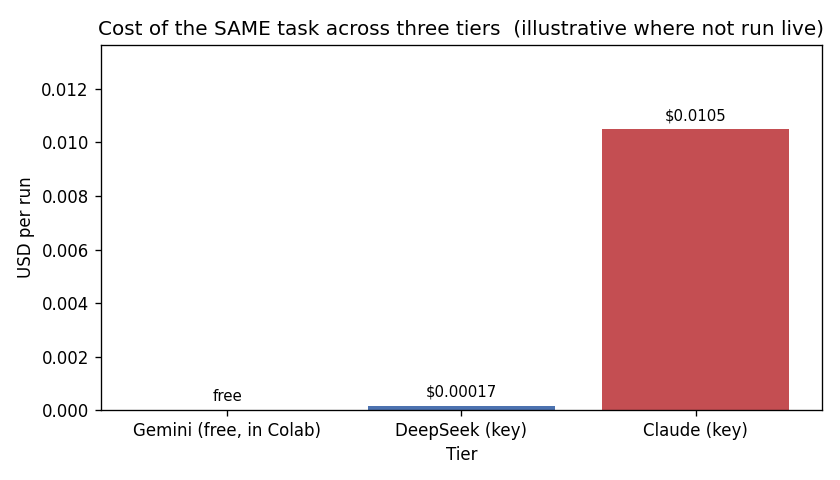

Free for exploring          -> Gemini, inside Colab.
A key for automating         -> DeepSeek runs without you, ~a fraction of a cent.
Premium for the hardest jobs -> Claude.


In [7]:
costs = tier_lab.costs_frame([gemini, deepseek, claude])
display(costs)
chart = tier_lab.make_cost_chart(costs, ".")
display(Image(filename=chart))

print("Free for exploring          -> Gemini, inside Colab.")
print("A key for automating         -> DeepSeek runs without you, ~a fraction of a cent.")
print("Premium for the hardest jobs -> Claude.")
